
Menghasilkan data latih sintetis...
Menyimpan data...
Dataset berhasil disimpan di: synthetic_avo_dataset.npz
Memvisualisasikan sampel data sintetis...


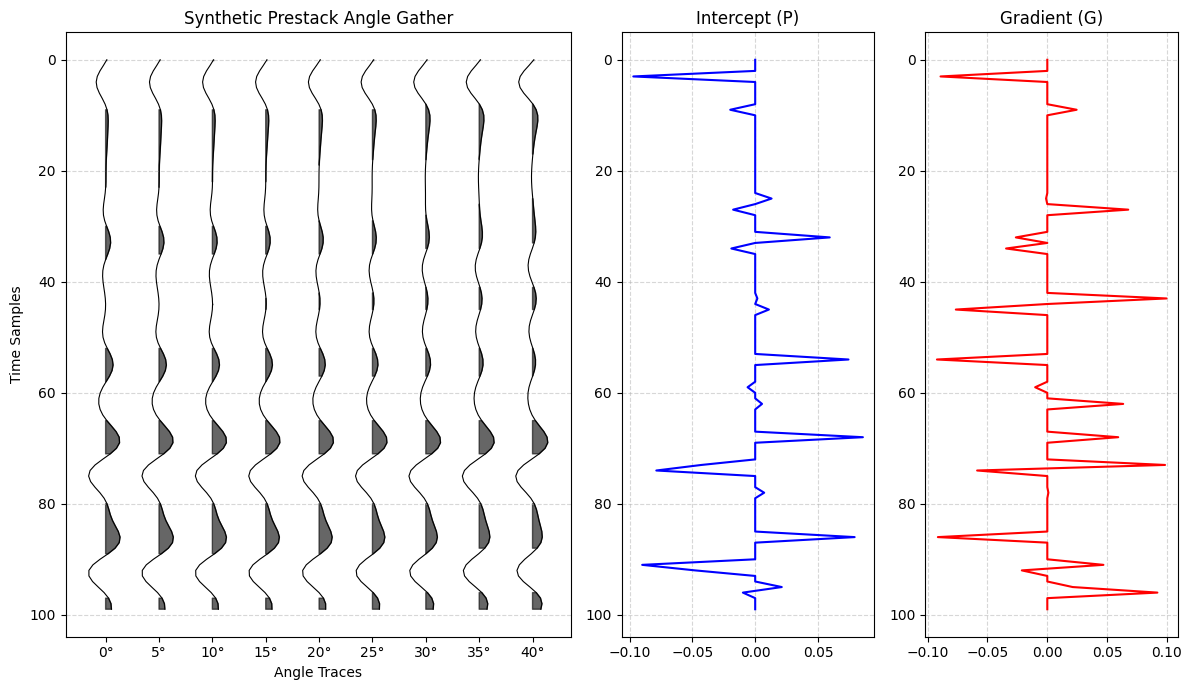

Membangun model CNN...


Memulai pelatihan model...
Epoch 1/20


125/125 [==============================] - 2s 8ms/step - loss: 6.7065e-04 - mae: 0.0114 - val_loss: 6.6130e-04 - val_mae: 0.0113
Epoch 2/20
125/125 [==============================] - 1s 6ms/step - loss: 6.6054e-04 - mae: 0.0118 - val_loss: 6.5191e-04 - val_mae: 0.0122
Epoch 3/20
125/125 [==============================] - 1s 6ms/step - loss: 6.4418e-04 - mae: 0.0127 - val_loss: 6.3332e-04 - val_mae: 0.0129
Epoch 4/20
125/125 [==============================] - 1s 6ms/step - loss: 6.2319e-04 - mae: 0.0133 - val_loss: 6.1526e-04 - val_mae: 0.0136
Epoch 5/20
125/125 [==============================] - 1s 7ms/step - loss: 6.0376e-04 - mae: 0.0138 - val_loss: 5.9730e-04 - val_mae: 0.0139
Epoch 6/20
125/125 [==============================] - 1s 6ms/step - loss: 5.8595e-04 - mae: 0.0141 - val_loss: 5.8369e-04 - val_mae: 0.0143
Epoch 7/20
125/125 [==============================] - 1s 6ms/step - loss: 5.7132e-04 - mae: 0.0143 - val_l

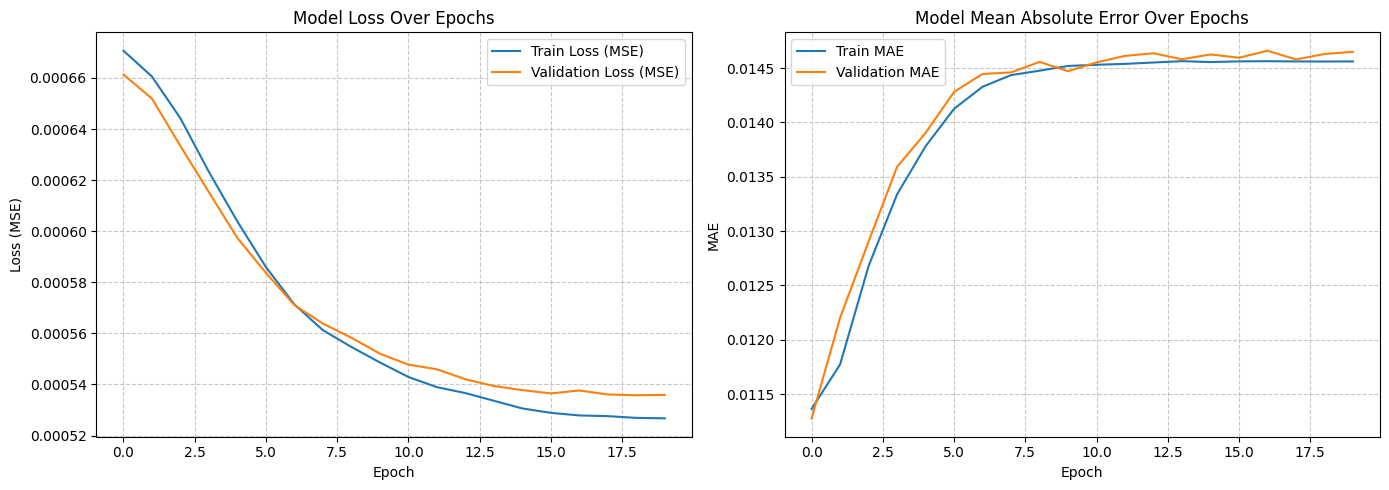

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. GENERASI DATA SINTETIS (FORWARD MODELING)
# ==========================================
def generate_synthetic_avo_data(num_samples=1000, time_steps=100, num_angles=5):
    """
    Menghasilkan data sintetis berupa prestack angle gathers beserta label P dan G.
    Berdasarkan hampiran Shuey 2-suku: R(theta) = P + G * sin^2(theta)
    """
    angles_deg = np.linspace(0, 40, num_angles)
    angles_rad = np.deg2rad(angles_deg)
    
    d_gathers = np.zeros((num_samples, time_steps, num_angles))
    p_labels = np.zeros((num_samples, time_steps))
    g_labels = np.zeros((num_samples, time_steps))
    
    f = 30.0 
    dt = 0.002
    t, w = generate_ricker(f, dt)
    
    for i in range(num_samples):
        P = np.random.uniform(-0.1, 0.1, time_steps)
        G = np.random.uniform(-0.1, 0.1, time_steps)
        
        sparsity_mask = np.random.choice([0, 1], size=time_steps, p=[0.8, 0.2])
        P = P * sparsity_mask
        G = G * sparsity_mask
        
        p_labels[i, :] = P
        g_labels[i, :] = G
        
        for j, theta in enumerate(angles_rad):
            R_theta = P + G * (np.sin(theta)**2)
            synthetic_trace = np.convolve(R_theta, w, mode='same')
            d_gathers[i, :, j] = synthetic_trace
            
    return d_gathers, p_labels, g_labels, angles_deg

def generate_ricker(f, dt, length=0.128):
    """Membuat Ricker wavelet standar untuk konvolusi."""
    t = np.arange(-length/2, (length-dt)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y

# ==========================================
# 2. VISUALISASI DAN PENYIMPANAN DATA
# ==========================================
def save_dataset(filepath, gathers, p_labels, g_labels):
    """Menyimpan data sintetis ke dalam format .npz terkompresi."""
    np.savez_compressed(filepath, gathers=gathers, p_labels=p_labels, g_labels=g_labels)
    print(f"Dataset berhasil disimpan di: {filepath}")

def plot_synthetic_gather(gather, p_label, g_label, angles):
    """Visualisasi angle gather dengan gaya wiggle trace beserta log P dan G."""
    time_steps = gather.shape[0]
    fig, axs = plt.subplots(1, 3, figsize=(12, 7), gridspec_kw={'width_ratios': [2, 1, 1]})
    
    # Plot Angle Gather (Wiggle Trace)
    for i, angle in enumerate(angles):
        offset = i * 0.5 # Jarak antar trace
        trace = gather[:, i] + offset
        axs[0].plot(trace, np.arange(time_steps), color='black', linewidth=0.8)
        axs[0].fill_betweenx(np.arange(time_steps), offset, trace, 
                             where=(trace > offset), color='black', alpha=0.6)
    
    axs[0].invert_yaxis()
    axs[0].set_title('Synthetic Prestack Angle Gather')
    axs[0].set_ylabel('Time Samples')
    axs[0].set_xlabel('Angle Traces')
    axs[0].set_xticks([i * 0.5 for i in range(len(angles))])
    axs[0].set_xticklabels([f"{int(a)}°" for a in angles])
    axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # Plot Intercept (P)
    axs[1].plot(p_label, np.arange(time_steps), color='blue')
    axs[1].invert_yaxis()
    axs[1].set_title('Intercept (P)')
    axs[1].grid(True, linestyle='--', alpha=0.5)
    
    # Plot Gradient (G)
    axs[2].plot(g_label, np.arange(time_steps), color='red')
    axs[2].invert_yaxis()
    axs[2].set_title('Gradient (G)')
    axs[2].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def plot_training_history(history):
    """Visualisasi loss (MSE) dan metrik (MAE) selama proses training."""
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss (MSE)
    axs[0].plot(history.history['loss'], label='Train Loss (MSE)')
    axs[0].plot(history.history['val_loss'], label='Validation Loss (MSE)')
    axs[0].set_title('Model Loss Over Epochs')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss (MSE)')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.7)
    
    # Plot MAE
    axs[1].plot(history.history['mae'], label='Train MAE')
    axs[1].plot(history.history['val_mae'], label='Validation MAE')
    axs[1].set_title('Model Mean Absolute Error Over Epochs')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('MAE')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. ARSITEKTUR CONVOLUTIONAL NEURAL NETWORK
# ==========================================
def build_avo_cnn(time_steps, num_angles):
    """Membangun arsitektur CNN untuk inversi AVO."""
    model = models.Sequential()
    model.add(layers.Input(shape=(time_steps, num_angles)))
    
    model.add(layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.AveragePooling1D(pool_size=2))
    
    model.add(layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.AveragePooling1D(pool_size=2))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(time_steps * 2))
    model.add(layers.Reshape((time_steps, 2)))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# ==========================================
# 4. PIPELINE UTAMA
# ==========================================
if __name__ == "__main__":
    TIME_STEPS = 100 
    NUM_ANGLES = 9   
    NUM_SAMPLES = 5000 
    DATA_PATH = "synthetic_avo_dataset.npz"
    
    # 1. Generate Data
    print("Menghasilkan data latih sintetis...")
    X_train, P_train, G_train, angles_deg = generate_synthetic_avo_data(
        num_samples=NUM_SAMPLES, 
        time_steps=TIME_STEPS, 
        num_angles=NUM_ANGLES
    )
    
    # 2. Simpan Data
    print("Menyimpan data...")
    save_dataset(DATA_PATH, X_train, P_train, G_train)
    
    # 3. Visualisasi Sampel Data (Indeks ke-0)
    print("Memvisualisasikan sampel data sintetis...")
    plot_synthetic_gather(X_train[0], P_train[0], G_train[0], angles_deg)
    
    # Target untuk model: Gabungkan P dan G -> shape (samples, time_steps, 2)
    y_train = np.stack((P_train, G_train), axis=-1)
    
    # 4. Bangun dan Latih Model
    print("Membangun model CNN...")
    cnn_model = build_avo_cnn(time_steps=TIME_STEPS, num_angles=NUM_ANGLES)
    
    print("Memulai pelatihan model...")
    history = cnn_model.fit(X_train, y_train, 
                            epochs=20, 
                            batch_size=32, 
                            validation_split=0.2,
                            verbose=1)
    
    # 5. Visualisasi Hasil Training
    print("Memvisualisasikan hasil pelatihan...")
    plot_training_history(history)